Descargando BTC...


[*********************100%***********************]  1 of 1 completed


Descargando MSTR...


[*********************100%***********************]  1 of 1 completed



--- ÉXITO ---
Filas alineadas y limpias: 3440
                                    BTC       MSTR
Datetime                                          
2024-02-20 14:00:00+00:00  52013.222656  68.650002
2024-02-20 15:00:00+00:00  51707.675781  69.806000
2024-02-20 16:00:00+00:00  51370.734375  67.699997
2024-02-20 17:00:00+00:00  51312.492188  68.503120
2024-02-20 18:00:00+00:00  51500.457031  69.597000


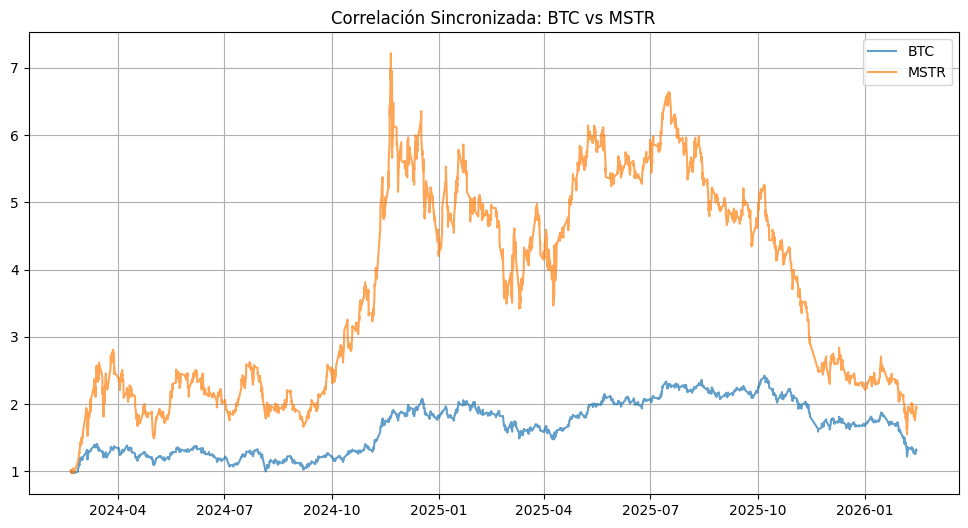

Guardado en 'datos_mstr_btc_1h.csv'


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. DESCARGA POR SEPARADO (Divide y vencerás)
print("Descargando BTC...")
# auto_adjust=True nos da el precio limpio directamente
btc = yf.download('BTC-USD', period='730d', interval='1h', auto_adjust=True)

print("Descargando MSTR...")
mstr = yf.download('MSTR', period='730d', interval='1h', auto_adjust=True)

# 2. LIMPIEZA DE COLUMNAS (Manejo del MultiIndex rebelde)
# A veces yfinance devuelve (Price, Ticker) y a veces solo (Price).
# Esta función asegura que nos quedamos solo con la columna 'Close' como una Serie limpia.
def limpiar_datos(df, ticker_name):
    # Si tiene columnas con niveles (Price, Ticker), extraemos 'Close'
    if isinstance(df.columns, pd.MultiIndex):
        try:
            # Intenta sacar la columna Close de ese ticker especifico
            return df.xs('Close', axis=1, level=0)[ticker_name]
        except:
            # Si falla, intenta sacar solo 'Close' si el nivel ticker no está claro
            return df['Close']
    else:
        # Si es un dataframe plano
        return df['Close']

# Aplicamos la limpieza
btc_clean = limpiar_datos(btc, 'BTC-USD')
mstr_clean = limpiar_datos(mstr, 'MSTR')

# 3. SINCRONIZACIÓN TEMPORAL (Aquí está la magia física)
# Convertimos todo a UTC para evitar líos de zonas horarias
btc_clean.index = btc_clean.index.tz_convert('UTC')
mstr_clean.index = mstr_clean.index.tz_convert('UTC')

# TRUCO: "Aplanar" los minutos. 
# Si MSTR es 13:30, lo convertimos a 13:00 para que coincida con BTC.
# .floor('H') redondea a la hora inferior.
mstr_clean.index = mstr_clean.index.floor('h')
btc_clean.index = btc_clean.index.floor('h')

# 4. FUSIÓN (MERGE)
# Ahora que los índices son idénticos (horas en punto), unimos.
df_final = pd.concat([btc_clean, mstr_clean], axis=1)
df_final.columns = ['BTC', 'MSTR']

# 5. LIMPIEZA FINAL
# Borramos filas donde falte uno de los dos (fines de semana, noches)
df_final = df_final.dropna()

print(f"\n--- ÉXITO ---")
print(f"Filas alineadas y limpias: {len(df_final)}")
print(df_final.head())

# 6. VISUALIZACIÓN
# Normalizamos para ver la comparativa
df_norm = df_final / df_final.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(df_norm.index, df_norm['BTC'], label='BTC', alpha=0.7)
plt.plot(df_norm.index, df_norm['MSTR'], label='MSTR', alpha=0.7)
plt.title('Correlación Sincronizada: BTC vs MSTR')
plt.legend()
plt.grid(True)
plt.show()

# 7. GUARDAR
df_final.to_csv('datos_mstr_btc_1h.csv')
print("Guardado en 'datos_mstr_btc_1h.csv'")

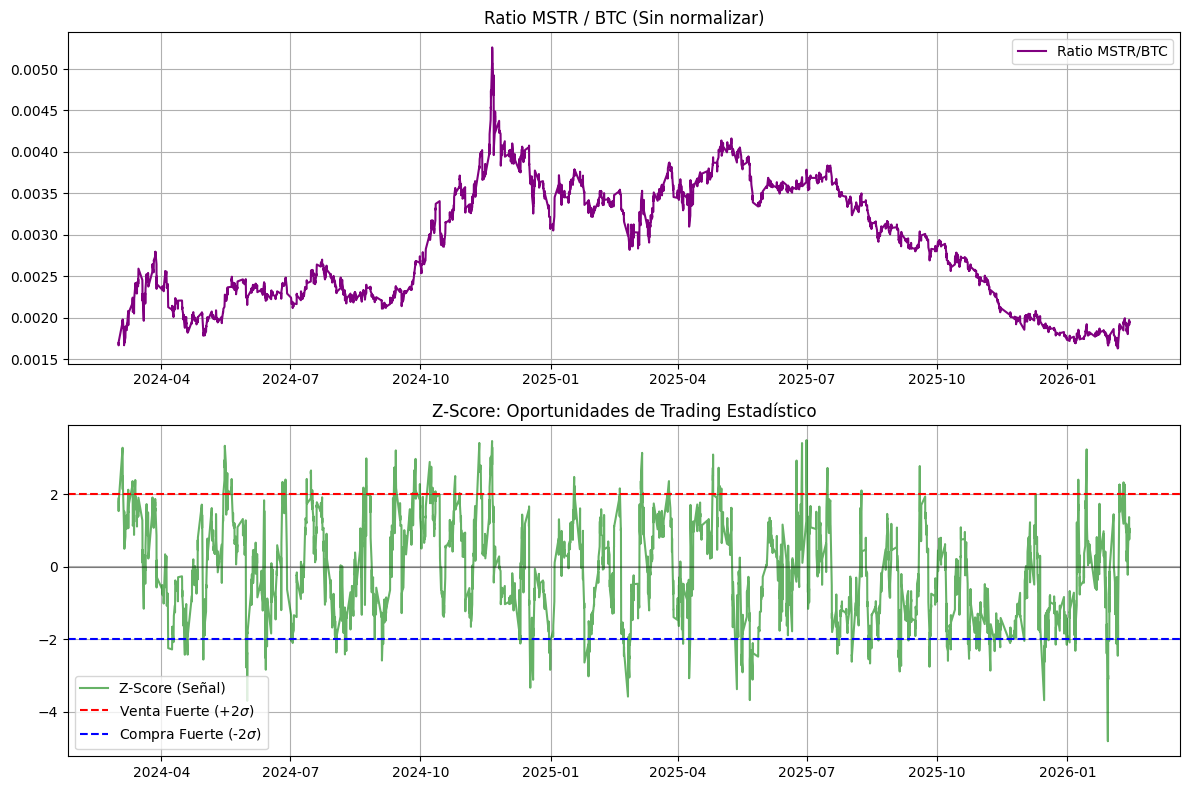

Dataset con features generado: 'datos_entrenamiento.csv'


In [2]:
# 1. CARGAR DATOS
df = pd.read_csv('datos_mstr_btc_1h.csv', index_col=0, parse_dates=True)

# 2. FEATURE ENGINEERING (Ingeniería de Variables)

# A) Retornos Logarítmicos (Velocidad del precio)
# Es mejor que el porcentaje simple porque es sumable en el tiempo y simétrico.
df['lret_btc'] = np.log(df['BTC'] / df['BTC'].shift(1))
df['lret_mstr'] = np.log(df['MSTR'] / df['MSTR'].shift(1))

# B) El Ratio Simple (Posición relativa)
df['ratio'] = df['MSTR'] / df['BTC']

# C) Indicadores Técnicos de la Relación (Dinámica del sistema)
# Usamos una ventana móvil (Rolling Window) para que el modelo se adapte al pasado reciente.
# Ventana de 1 semana (aprox 40 horas de trading activo o 168h naturales, probemos con 60 periodos de datos)
WINDOW = 60 

# Media móvil y Desviación estándar del ratio
df['ratio_mean'] = df['ratio'].rolling(window=WINDOW).mean()
df['ratio_std'] = df['ratio'].rolling(window=WINDOW).std()

# D) Z-SCORE (La señal normalizada)
# Fórmula: (Valor actual - Media) / Desviación Estándar
# Esto nos dice: "¿Qué tan rara es la separación actual entre BTC y MSTR?"
df['z_score'] = (df['ratio'] - df['ratio_mean']) / df['ratio_std']

# Limpiamos los NaN que generan las ventanas móviles al principio
df = df.dropna()

# 3. VISUALIZACIÓN DE LA SEÑAL
# Esto es lo que verá tu bot. Ya no ve precios que suben al infinito.
# Ve una señal que oscila alrededor de cero.
plt.figure(figsize=(12, 8))

# Subplot 1: El Ratio
plt.subplot(2, 1, 1)
plt.plot(df.index, df['ratio'], label='Ratio MSTR/BTC', color='purple')
plt.title('Ratio MSTR / BTC (Sin normalizar)')
plt.legend()
plt.grid(True)

# Subplot 2: El Z-Score (Lo que usa el bot)
plt.subplot(2, 1, 2)
plt.plot(df.index, df['z_score'], label='Z-Score (Señal)', color='green', alpha=0.6)
# Dibujamos bandas de "exceso" (2 Sigma)
plt.axhline(2, color='red', linestyle='--', label='Venta Fuerte (+2$\sigma$)')
plt.axhline(-2, color='blue', linestyle='--', label='Compra Fuerte (-2$\sigma$)')
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.title('Z-Score: Oportunidades de Trading Estadístico')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Guardamos el dataset enriquecido
df.to_csv('datos_entrenamiento.csv')
print("Dataset con features generado: 'datos_entrenamiento.csv'")

In [3]:
# 1. CARGAR
df = pd.read_csv('datos_entrenamiento.csv', index_col=0, parse_dates=True)

# 2. CREAR EL TARGET (El objetivo a predecir)
# Queremos saber si el Ratio subirá o bajará en el futuro.
# HORIZONTE DE PREDICCIÓN: 5 horas (barras)
PREDICTION_HORIZON = 5

# Creamos la columna del futuro (Shift negativo mueve los datos hacia "atrás" en el índice)
# Es decir, en la fila de las 10:00, ponemos el precio de las 15:00.
df['future_ratio'] = df['ratio'].shift(-PREDICTION_HORIZON)

# Definimos el Target:
# 1 (Compra/Long): Si el ratio futuro es MAYOR que el ratio actual + un pequeño umbral (comisiones)
# 0 (Venta/Short/Nada): Si baja o se mantiene.
THRESHOLD = 0.005 # 0.5% de margen para cubrir comisiones

df['Target'] = (df['future_ratio'] > df['ratio'] * (1 + THRESHOLD)).astype(int)

# Limpiamos los NaN del final (las últimas 5 horas no tienen futuro conocido)
df = df.dropna()

# 3. VERIFICAR BALANCE DE CLASES
# Esto es CRÍTICO en IA.
# Si tienes 90% de ceros y 10% de unos, la IA aprenderá a decir siempre "0" y acertará el 90%.
# Queremos que esté equilibrado (cerca de 50/50).
conteo = df['Target'].value_counts()
print(f"Distribución de Clases:\n{conteo}")
print(f"Porcentaje de Compras (1): {conteo[1] / len(df) * 100:.2f}%")

# 4. PREPARACIÓN FINAL PARA PYTORCH
# Seleccionamos solo las columnas numéricas que usará la red
# Quitamos los precios absolutos (BTC, MSTR) porque confunden a la red (no son estacionarios)
features = ['lret_btc', 'lret_mstr', 'ratio', 'z_score', 'ratio_mean', 'ratio_std']
target = ['Target']

final_data = df[features + target]

# Guardamos el dataset listo para la fase de Deep Learning
final_data.to_csv('datos_finales_IA.csv')
print("Dataset final guardado: 'datos_finales_IA.csv'")
print("Variables de entrada:", features)

Distribución de Clases:
Target
0    2017
1    1359
Name: count, dtype: int64
Porcentaje de Compras (1): 40.25%
Dataset final guardado: 'datos_finales_IA.csv'
Variables de entrada: ['lret_btc', 'lret_mstr', 'ratio', 'z_score', 'ratio_mean', 'ratio_std']
